In [ ]:
import json
from pathlib import Path
from mat1510 import verify_answer, extract_answer
import matplotlib.pyplot as plt

In [19]:
# base_dir = 'C:/Users/nicho/Downloads/aime_full_single_pass_20251123_154027/'
# problems = []
# ground_truth = {}

# base_dir_path = Path(base_dir)
    
# # Load the config
# with open(base_dir_path / 'experiment.json', 'r') as f:
#     experiment_data = json.load(f)

# num_rollouts = experiment_data['config']['num_rollouts']

# for problem in experiment_data['problems']:
#     problems.append(str(problem['index']))
#     ground_truth[problems[-1]] = problem['ground_truth']

num_rollouts = 960
ground_truth = {'0': "204", '12': "540"}
problems = ['0', '12']
base_dir = 'C:/Users/nicho/Downloads/aime_full_single_pass_20251123_154027/'

In [24]:
# Parses all paths and returns them (no saving)
def parse_all_paths(save_dir, ground_truth=None):
    """Load a reasoning graph from saved files and extract all paths with entropy."""
    save_dir = Path(save_dir)
    
    # Load graph structure
    with open(save_dir / 'graph_structure.json', 'r') as f:
        graph_data = json.load(f)
        graph_structure = graph_data['graph']
        nodes = graph_structure['nodes']
            
    # Using dfs: (node_id, tokens_with_entropy)
    stack = [('0', [])]
    all_paths = []
    
    while len(stack) > 0:
        node_id, tokens_entropy = stack.pop()
        node = nodes[node_id]

        # Only include non-forking tokens in the path
        if not node.get('is_forking_token', False):
            new_tokens_entropy = tokens_entropy + [[node["value"], node["metric_value"]]]
        else:
            # Skip forking nodes
            new_tokens_entropy = tokens_entropy
        
        next_tokens = node['next_tokens']

        if len(next_tokens) == 0:
            # End of path - reconstruct completion to check correctness
            completion = "".join([token for token, _ in new_tokens_entropy])
            
            is_correct = None
            if ground_truth is not None:
                is_correct = verify_answer(ground_truth, completion)
            
            all_paths.append({
                "tokens_with_entropy": new_tokens_entropy,
                "is_correct": is_correct
            })
        else:
            for next_token in next_tokens:
                stack.append((str(next_token), new_tokens_entropy))
    
    return all_paths

In [3]:
# Process all rollouts and build nested structure
base_dir = 'experiments/aime_full_20251120_162143/'
base_dir_path = Path(base_dir)

# Load experiment config
with open(base_dir_path / 'experiment.json', 'r') as f:
    experiment_data = json.load(f)

num_rollouts = experiment_data['config']['num_rollouts']

# Build ground truth dictionary
ground_truth = {}
for problem in experiment_data['problems']:
    ground_truth[problem['index']] = problem['ground_truth']

# Build nested structure: {problem_idx: {rollout_idx: [paths...]}}
all_paths_nested = {}

for problem_idx in ground_truth.keys():
    print(f"Processing problem {problem_idx}...")
    all_paths_nested[problem_idx] = {}
    
    for rollout_idx in range(num_rollouts):
        rollout_dir = base_dir_path / f'problem_{problem_idx}' / f'rollout_{rollout_idx}'
        
        if not rollout_dir.exists():
            continue
        
        # Parse paths for this rollout
        paths = parse_all_paths(rollout_dir, ground_truth[problem_idx])
        all_paths_nested[problem_idx][rollout_idx] = paths

# Save to single JSON file
output_path = base_dir_path / 'paths.json'
with open(output_path, 'w') as f:
    json.dump(all_paths_nested, f, indent=2)

print(f"Done! Saved all paths to {output_path}")

Processing problem 0...
Processing problem 1...
Processing problem 6...
Processing problem 12...
Processing problem 22...
Processing problem 25...
Done! Saved all paths to experiments/aime_full_20251120_162143/paths.json


In [26]:
# Finding all of the paths that the graph went through
for problem in problems:
    for rollout in range(num_rollouts):
        cur_dir = base_dir + 'problem_' + problem + '/rollout_' + str(rollout)
        parse_all_paths(cur_dir)
        

In [22]:
def group_format(cur_dir, ground_truth):
    cur_dir = Path(cur_dir)
    lengths = []
    
    # Load graph structure
    with open(cur_dir / 'paths.json', 'r') as f:
        answers = json.load(f)

    for answer in answers:
        ans_dict = {}
        extracted_answer = extract_answer(answer['completion'])

        # Add the length
        ans_dict['length'] = answer['length']
        ans_dict['completion'] = answer['completion']

        # Add if it was right
        if extracted_answer == float(ground_truth):
            ans_dict['right'] = True
        else:
            ans_dict['right'] = False

        lengths.append(ans_dict)
    return lengths

In [31]:
groups = []
group_size = 32
tmp_group = []


for problem in problems:
    for rollout in range(num_rollouts):
        cur_dir = base_dir + 'problem_' + problem + '/rollout_' + str(rollout)
        answer = ground_truth[problem]
        tmp_group.extend(group_format(cur_dir, answer))
        
        if rollout % group_size == 0 and rollout != 0:
            groups.append(tmp_group)
            tmp_group = []


In [32]:
#Save this for later analysis
with open("aime_single_pass.json", "w") as f:
    json.dump(groups, f, indent=2)

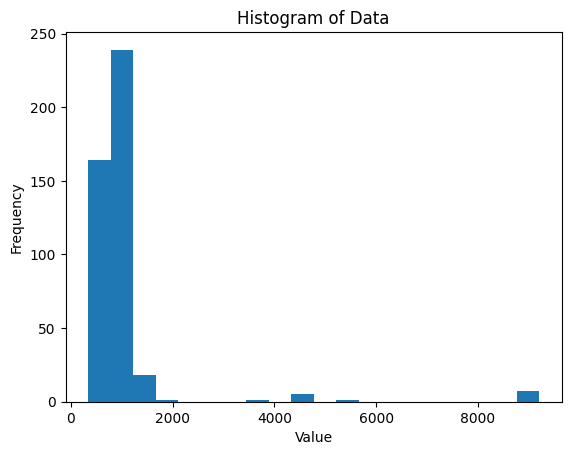

In [12]:
plt.hist(values, bins=20)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Data")
plt.show()

In [13]:
print(np.mean(values))
print(np.std(values))

1049.5825688073394
1145.9506189902093


In [90]:
# This is for loading an experiment that does not have a full graph
experiment_dir = 'C:/Users/nicho/Downloads/aim_1_20251113_025853/'
experiment_dir = Path(experiment_dir)

with open(experiment_dir / 'experiment.json', 'r') as f:
    single_pass_data = json.load(f)

single_pass_lens = {}

for problem_name in single_pass_data['results']:
    problem = single_pass_data['results'][problem_name]
    single_pass_lens[problem['problem_idx']] = []
    ground_truth = problem['ground_truth']

    for rollout in problem['rollouts']:
        if rollout['is_correct']:
            single_pass_lens[problem['problem_idx']].append(rollout['num_tokens'])


print(single_pass_lens)



{0: [1031, 1071, 1219, 1187, 1009, 1189, 954, 1054, 1087, 932, 1011, 1230, 1186, 996, 1107, 1184, 842, 1429, 1153, 999, 1046, 1293], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [1168, 476, 861, 436, 611, 550, 1171, 667, 431, 558, 521, 510, 605, 421, 499, 839, 517, 658, 1135, 571, 611, 486, 511, 633, 563, 534, 451, 371, 332, 467, 446, 883, 466, 575, 358, 419, 451, 617, 635, 582], 8: [718], 9: [924, 782, 914, 751, 959, 1086, 751, 707, 684, 972, 610, 977, 666, 797, 778, 704, 733, 647, 583, 779, 909, 635, 904, 774, 707, 672]}


In [91]:
#Save this for later analysis
with open("aime1.json", "w") as f:
    json.dump(single_pass_lens, f, indent=2)

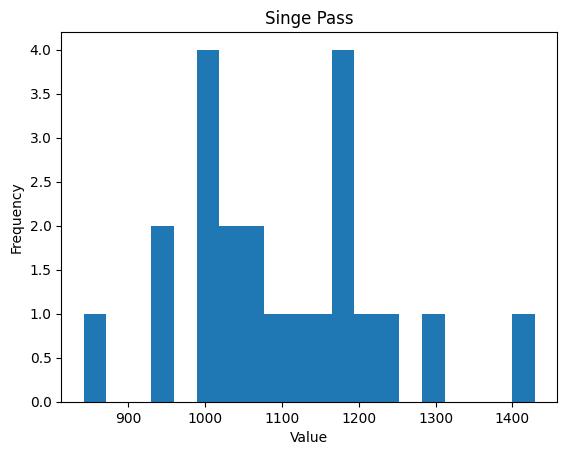

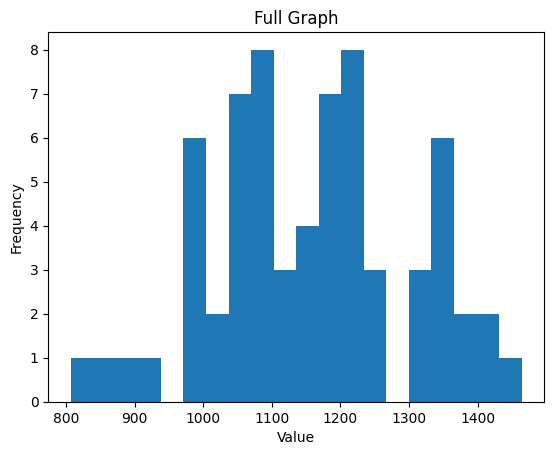

In [ ]:
# Load two experiments and compare them
single_pass_path = "C:/Users/nicho/OneDrive/Documents/Masters/Math DL/Project/Correct_ans_lens/single_pass/aime1.json"
full_graph_path = "C:/Users/nicho/OneDrive/Documents/Masters/Math DL/Project/Correct_ans_lens/full_graph/aime1.json"

with open(single_pass_path, 'r') as f:
    single_pass_dict = json.load(f)

with open(full_graph_path, 'r') as f:
    full_graph_dict = json.load(f)

plt.hist(single_pass_dict['0'], bins=20)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Singe Pass")
plt.show()

plt.hist(full_graph_dict['0'], bins=20)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Full Graph")
plt.show()

In [96]:
smallest_single = np.min(single_pass_dict['0'])
print(f'Smallest from single pass: {smallest_single}')
avg_single = np.mean(single_pass_dict['0'])
print(f'Avg from single pass: {avg_single}')
std_single = np.std(single_pass_dict['0'])
print(f'Std from single pass: {std_single}')
print()

smallest_full = np.min(full_graph_dict['0'])
print(f'Smallest from full graph: {smallest_full}')
avg_full = np.mean(full_graph_dict['0'])
print(f'Avg from full graph: {avg_full}')
std_full = np.std(full_graph_dict['0'])
print(f'Std from full graph: {std_full}')

Smallest from single pass: 842
Avg from single pass: 1100.409090909091
Std from single pass: 130.29220973394908

Smallest from full graph: 807
Avg from full graph: 1157.378787878788
Std from full graph: 143.01078208467413
